# Import Library

In [210]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

# Load Dataset

In [211]:
df = pd.read_csv("data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Information

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Missing Values

In [213]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Fill Missing Values

In [214]:
# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


# Label Encoding

In [215]:
label_encoder = LabelEncoder()

df["Sex"] = label_encoder.fit_transform(df["Sex"])
df["Embarked"] = label_encoder.fit_transform(df["Embarked"])

In [216]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [217]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


# Features and Target Variable

In [218]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (891, 7)
Target Shape   : (891,)


# Train-Test Split

In [219]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (712, 7)
Testing Samples  : (179, 7)


# Train Random Forest Classifier

In [220]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


# Initial Prediction

In [221]:
y_pred = rf_model.predict(X_test)

print("Prediction completed successfully!")

Prediction completed successfully!


# Initial Model Performance

In [222]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8268
Precision: 0.8065
Recall   : 0.7246
F1 Score : 0.7634


# Hyperparameter Tuning

In [223]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best F1 Score:
0.7603002644911154


## Best Tuned Model

In [224]:
best_model = grid_search.best_estimator_

print(best_model)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)


## Prediction using Tuned Model

In [225]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Performance of Tuned Model")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Performance of Tuned Model
----------------------------------------
Accuracy : 0.8101
Precision: 0.8182
Recall   : 0.6522
F1 Score : 0.7258


# Probability Calibration

In [226]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",   # Platt Scaling
    cv=5
)

calibrated_model.fit(X_train, y_train)

print("Model calibrated successfully!")

Model calibrated successfully!


# Predict Calibrated Probabilities

In [227]:
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

print("First 10 Predicted Probabilities:")
print(y_prob[:10])

First 10 Predicted Probabilities:
[0.14907954 0.14559635 0.13903094 0.1064306  0.65244395 0.33457549
 0.88794517 0.63864573 0.4539535  0.14527516]


# Calibration Curve

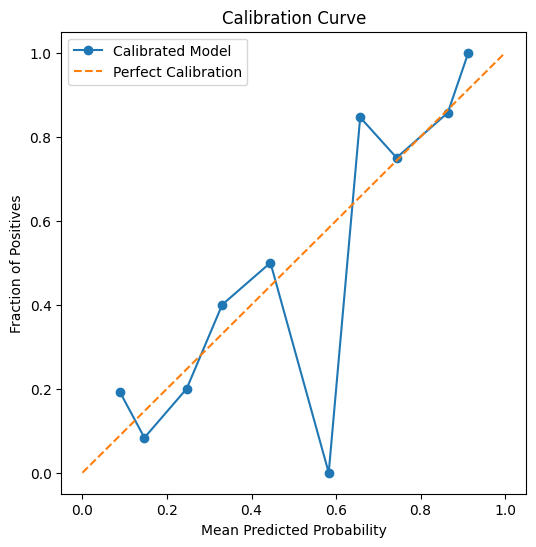

In [228]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o', label="Calibrated Model")
plt.plot([0,1],[0,1], linestyle='--', label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")

plt.legend()

plt.savefig("outputs/calibration_curve.png")

plt.show()

# ROC-AUC Score

In [229]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score : {roc_auc:.4f}")

ROC-AUC Score : 0.8408


# Find the Best Threshold

In [230]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1 Score for each threshold
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Best Threshold : {best_threshold:.4f}")
print(f"Best F1 Score  : {f1_scores[best_index]:.4f}")

Best Threshold : 0.3236
Best F1 Score  : 0.7671


# Predictions Using Best Threshold

In [231]:
y_pred_best = (y_prob >= best_threshold).astype(int)

# Evaluation After Threshold Optimization

In [232]:
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Performance After Threshold Optimization")
print("-" * 45)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Performance After Threshold Optimization
---------------------------------------------
Accuracy : 0.8101
Precision: 0.7273
Recall   : 0.8116
F1 Score : 0.7671


# Threshold vs F1 Score

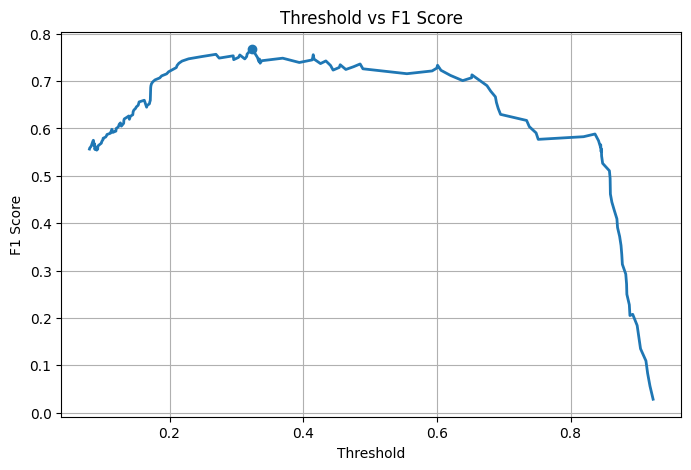

In [233]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores, linewidth=2)
plt.scatter(best_threshold, f1_scores[best_index], marker='o')

plt.title("Threshold vs F1 Score")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.grid(True)

plt.savefig("outputs/threshold_plot.png")

plt.show()

# Confusion Matrix

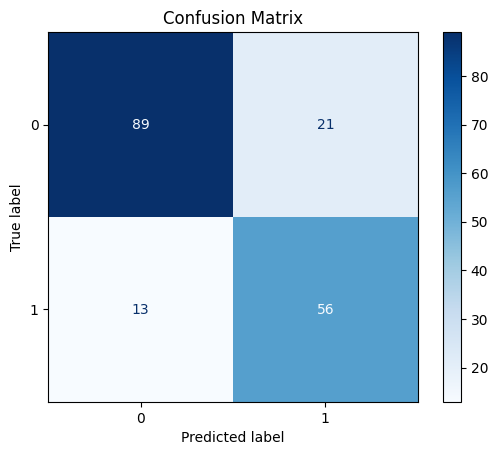

In [234]:
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("outputs/confusion_matrix.png")

plt.show()

# ROC Curve

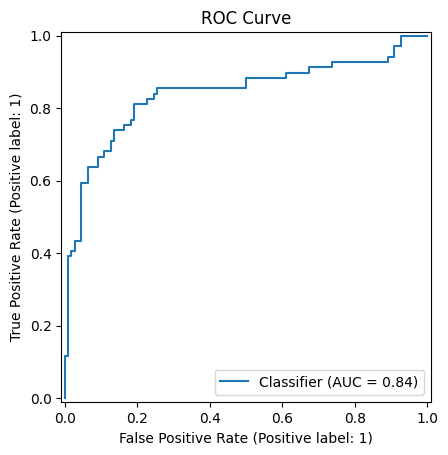

In [235]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")

plt.savefig("outputs/roc_curve.png")

plt.show()

# Segment-wise Analysis

In [236]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = y_pred_best

print("Performance by Gender")

for gender in sorted(results["Sex"].unique()):

    subset = results[results["Sex"] == gender]

    acc = accuracy_score(
        subset["Actual"],
        subset["Prediction"]
    )

    gender_name = "Female" if gender == 0 else "Male"

    print(f"{gender_name} Accuracy : {acc:.4f}")

Performance by Gender
Female Accuracy : 0.8852
Male Accuracy : 0.7712


# Passenger Class Performance

In [237]:
print("Performance by Passenger Class")

for pclass in sorted(results["Pclass"].unique()):

    subset = results[results["Pclass"] == pclass]

    acc = accuracy_score(
        subset["Actual"],
        subset["Prediction"]
    )

    print(f"Class {pclass} Accuracy : {acc:.4f}")

Performance by Passenger Class
Class 1 Accuracy : 0.6444
Class 2 Accuracy : 0.9118
Class 3 Accuracy : 0.8500


# Save Model

In [238]:
joblib.dump(
    calibrated_model,
    "models/calibrated_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Error Handling

In [239]:
try:
    test_prob = calibrated_model.predict_proba(X_test)
    print("Prediction successful!")
except Exception as e:
    print("Error:", e)

Prediction successful!


# Verify Saved Model

In [240]:
loaded_model = joblib.load("models/calibrated_model.pkl")

sample_prediction = loaded_model.predict(X_test[:5])

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[0 0 0 0 1]


# Final Summary

In [241]:
print("=" * 60)
print("TASK 12 - BINARY CLASSIFICATION COMPLETED")
print("=" * 60)

print(f"Best Threshold : {best_threshold:.4f}")
print(f"ROC-AUC Score  : {roc_auc:.4f}")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

print("\nOutput Files Generated:")
print("- calibration_curve.png")
print("- threshold_plot.png")
print("- confusion_matrix.png")
print("- roc_curve.png")
print("- calibrated_model.pkl")

print("\nTask completed successfully!")

TASK 12 - BINARY CLASSIFICATION COMPLETED
Best Threshold : 0.3236
ROC-AUC Score  : 0.8408
Accuracy       : 0.8101
Precision      : 0.7273
Recall         : 0.8116
F1 Score       : 0.7671

Output Files Generated:
- calibration_curve.png
- threshold_plot.png
- confusion_matrix.png
- roc_curve.png
- calibrated_model.pkl

Task completed successfully!
